# SARIMA Residual Analysis

## Purpose
Evaluates the residuals of the two best SARIMA configurations identified by the grid search to assess whether any systematic error structure remains. Residuals should be approximately **white noise**: zero mean, constant variance, and no significant autocorrelation.

A non-zero mean in the residuals indicates a bias that can be estimated and corrected in the next stage.

Two candidates are evaluated in sequence:
- **Candidate 1:** SARIMA(1,0,0)(2,0,0,12)
- **Candidate 2:** SARIMA(2,0,1)(1,1,0,12)

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)

## Outputs
- Residual summary statistics and distribution plots for each candidate.

In [1]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt

## Load Training Data

In [2]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Train / Test Split

50/50 split, consistent with all preceding notebooks.

In [3]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Candidate 1: Walk-Forward Validation — SARIMA(1,0,0)(2,0,0,12)

Generate one-step-ahead forecasts using the first grid-search candidate. `SARIMAX` fits the raw series directly; no manual differencing is applied. True observations are appended to history at each step to keep the model updated.

In [4]:
# walk-forward validation using the best order from grid_sarima
# Update order and seasonal_order below with the grid search result before running
order = (1, 0, 0)
seasonal_order = (2, 0, 0, 12)
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test[i])

## Candidate 1: Residual Summary Statistics

Compute the residuals (`actual − predicted`) and call `describe()`. Pay particular attention to the **mean**: a value significantly different from zero signals a systematic bias that should be explicitly corrected before deployment.

In [5]:
# residual summary — non-zero mean indicates systematic bias
residuals = [test[i] - predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                 0
count    47.000000
mean   -421.896172
std     776.023335
min   -2309.069575
25%    -719.820813
50%    -386.367978
75%     178.278612
max    1241.494914


## Candidate 1: Residual Distribution

A histogram and KDE of the residuals. Ideally these should be approximately symmetric and bell-shaped, centred near zero. Skewness or heavy tails suggest the model is leaving structure unexplained.

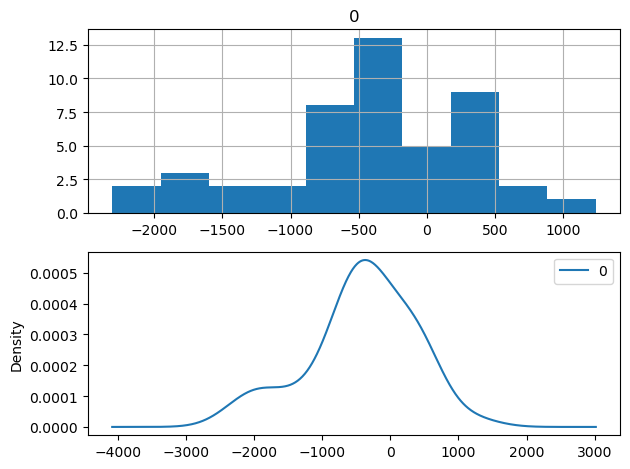

In [6]:
# distribution of residuals
plt.figure()
plt.subplot(211)
residuals.hist(ax=plt.gca())
plt.subplot(212)
residuals.plot(kind='kde', ax=plt.gca())
plt.tight_layout()
plt.show()

## Candidate 2: Walk-Forward Validation — SARIMA(2,0,1)(1,1,0,12)

Generate one-step-ahead forecasts using the second grid-search candidate. The `D=1` seasonal difference is handled internally by `SARIMAX`.

In [7]:
# walk-forward validation using the best order from grid_sarima
# Update order and seasonal_order below with the grid search result before running
order = (2, 0, 1)
seasonal_order = (1, 1, 0, 12)
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    model = SARIMAX(history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    history.append(test[i])

## Candidate 2: Residual Summary Statistics

Same analysis as Candidate 1. The residual mean from this cell is the bias constant to carry forward into `bias_corrected_sarima.ipynb`.

In [8]:
# residual summary — non-zero mean indicates systematic bias
residuals = [test[i] - predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                 0
count    47.000000
mean    -58.604374
std     909.975615
min   -2482.602058
25%    -441.599531
50%     -25.136929
75%     490.972168
max    2397.895719


## Candidate 2: Residual Distribution

A histogram and KDE of the residuals for the second candidate. Compare the distribution shape to Candidate 1 to assess which model leaves less unexplained structure.

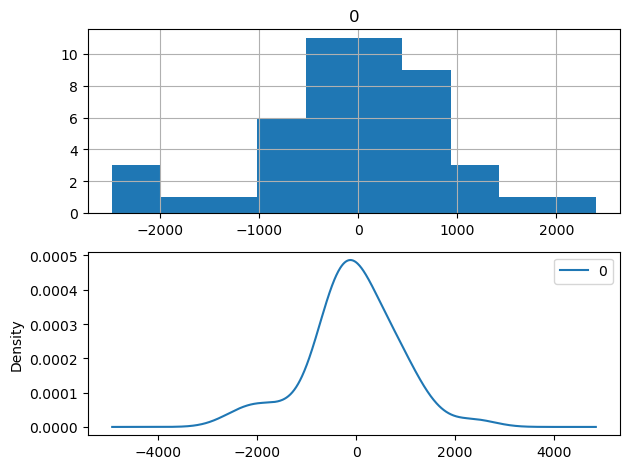

In [9]:
# distribution of residuals
plt.figure()
plt.subplot(211)
residuals.hist(ax=plt.gca())
plt.subplot(212)
residuals.plot(kind='kde', ax=plt.gca())
plt.tight_layout()
plt.show()